# Phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA)

Notebook này thực hiện phân tích dữ liệu ban đầu cho hệ thống gợi ý sản phẩm (Recommendation System).

## Mục tiêu

- Hiểu cấu trúc của tập dữ liệu
- Thống kê số lượng user, sản phẩm và tương tác
- Phân tích các loại tương tác của người dùng
- Phân tích phân bố giá sản phẩm
- Xác định các sản phẩm phổ biến

Kết quả của bước EDA sẽ giúp định hướng cho các bước tiếp theo như **tiền xử lý dữ liệu (preprocessing)** và **xây dựng mô hình gợi ý (recommendation model)**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
users = pd.read_csv("../data/raw/users.csv")
interactions = pd.read_csv("../data/raw/user_interactions.csv")
products = pd.read_parquet("../data/raw/products.parquet")

In [4]:
# vì trong parquet của product không có cột product id, nên ta sử dụng index để làm id
products = products.reset_index(drop=True)
products.insert(0, "product_id", products.index)

In [5]:
users.head()

,user_id,name,gender,age,created_at
0,1,Alexander Hill,Male,56,2024-07-27 08:37:46
1,2,Brian Yang,Other,23,2025-04-03 14:02:55
2,3,Jennifer Johnson,Female,17,2024-07-23 19:23:13
3,4,Lindsay Hoffman,Female,33,2025-08-14 03:15:09
4,5,Joshua Robinson,Male,31,2025-05-07 16:23:17


In [6]:
products.head()

,product_id,product_name,brand,category,style,type,model,purpose,color,material,currency,price,image_url,source_url,processed_at
0,0,$1250 Church's Consul Black Men’s Leather Cap ...,Church's,Men,Oxford,Dress,Church's Consul,Casual,Black,Leather,USD,128.000000,https://i.ebayimg.com/images/g/tmYAAeSw0pJo4ad...,https://www.ebay.com/itm/366178394996,2026-02-07 04:25:46.048
1,1,(size 4-11) adidas Samba Black,adidas,Men,Sneaker,Athletic,adidas Samba,Running & Jogging,Black,Leather,USD,64.989998,https://i.ebayimg.com/images/g/M5MAAeSwpj9pFY7...,https://www.ebay.com/itm/336065744195,2026-02-07 04:25:46.048
2,2,(size 4-11) adidas Samba White,adidas,Men,Sneaker,Athletic,adidas Samba,Running & Jogging,White,Leather,USD,59.990002,https://i.ebayimg.com/images/g/CBgAAeSwEp1pdIF...,https://www.ebay.com/itm/336068480331,2026-02-07 04:25:46.048
3,3,** NEW ** Kizik Men's Slip On Austin Casual Sh...,Kizik,Men,Sneaker,Casual,Kizik Austin,Casual,Brown,Synthetic,USD,36.189999,https://i.ebayimg.com/images/g/jrIAAeSwlklpT4M...,https://www.ebay.com/itm/376809253727,2026-02-07 04:25:46.048
4,4,***Adidas BW Army White Power Green Gum Beige ...,adidas,Men,Sneaker,Athletic,adidas BW Army,Basketball,White,Leather,USD,89.970001,https://i.ebayimg.com/images/g/xM0AAeSwj6NpfhR...,https://www.ebay.com/itm/287112603651,2026-02-07 04:25:46.048


In [7]:
interactions.head()

,interaction_id,user_id,product_id,interaction_type,quantity,interaction_time
0,1,610,19,View,1,2025-12-15 20:31:09
1,2,944,10,View,1,2026-01-03 08:01:04
2,3,450,4,Purchase,2,2026-02-02 03:11:06
3,4,706,10,AddToCart,1,2026-01-11 10:38:16
4,5,717,13,AddToCart,1,2026-01-18 05:25:17


In [8]:
# CHECK MISSING VALUES
print("Users missing values")
print(users.isnull().sum())

print("\nProducts missing values")
print(products.isnull().sum())

print("\nInteractions missing values")
print(interactions.isnull().sum())

Users missing values
user_id       0
name          0
gender        0
age           0
created_at    0
dtype: int64

Products missing values
product_id      0
product_name    0
brand           0
category        0
style           0
type            0
model           0
purpose         0
color           0
material        0
currency        0
price           0
image_url       0
source_url      0
processed_at    0
dtype: int64

Interactions missing values
interaction_id      0
user_id             0
product_id          0
interaction_type    0
quantity            0
interaction_time    0
dtype: int64


In [9]:
print("Users shape:", users.shape)
print("Products shape:", products.shape)
print("Interactions shape:", interactions.shape)

Users shape: (1000, 5)
Products shape: (2079, 15)
Interactions shape: (5000, 6)


In [14]:
# CHECK DUPLICATES
print("Duplicate users:", users.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())
print("Duplicate interactions:", interactions.duplicated().sum())

Duplicate users: 0
Duplicate products: 0
Duplicate interactions: 0


In [10]:
print("Total users:", users["user_id"].nunique())
print("Total products:", products["product_id"].nunique())
print("Total interactions:", len(interactions))

Total users: 1000
Total products: 2079
Total interactions: 5000


In [11]:
interactions["interaction_type"].value_counts()

interaction_type
View         3526
AddToCart     744
Purchase      460
Like          270
Name: count, dtype: int64

In [15]:
# INTERACTIONS PER USER
interactions_per_user = interactions.groupby("user_id").size()

print(interactions_per_user.describe())


count    992.000000
mean       5.040323
std        2.199988
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       15.000000
dtype: float64


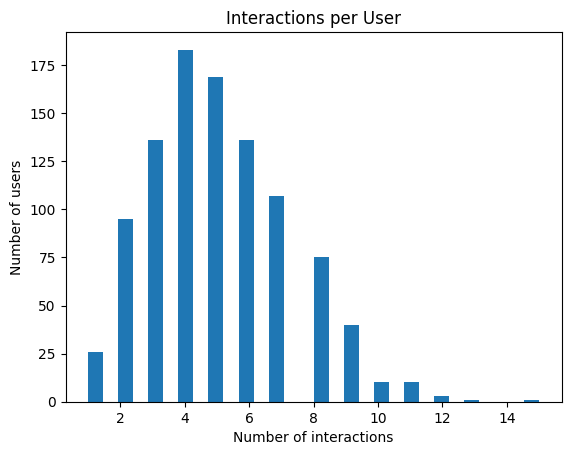

In [17]:
plt.hist(interactions_per_user, bins=30)
plt.title("Interactions per User")
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")
plt.show()

### Phân bố số lượng tương tác theo người dùng

Biểu đồ trên thể hiện phân bố số lượng tương tác (interactions) của mỗi người dùng trong hệ thống.

**Nhận xét:**

- Phần lớn người dùng có khoảng **3 đến 7 lượt tương tác** với sản phẩm.
- Số lượng tương tác phổ biến nhất tập trung quanh **4–5 interactions**.
- Chỉ có một số ít người dùng có **trên 10 lượt tương tác**, cho thấy đây là nhóm người dùng hoạt động nhiều hơn.

**Ý nghĩa:**

- Dữ liệu cho thấy hành vi người dùng tương đối **sparse (thưa)**, đây là đặc điểm phổ biến trong các hệ thống gợi ý.
- Khi phần lớn người dùng chỉ có ít tương tác, hệ thống gợi ý cần tận dụng các phương pháp như:
  - **similarity-based recommendation**
  - **feature-based recommendation**
- Những người dùng có nhiều tương tác sẽ cung cấp **tín hiệu mạnh hơn cho việc học sở thích người dùng**.

In [12]:
products["price"].describe()

count    2079.000000
mean       99.056702
std        83.843941
min         0.990000
25%        49.950001
50%        75.000000
75%       129.745003
max       859.989990
Name: price, dtype: float64

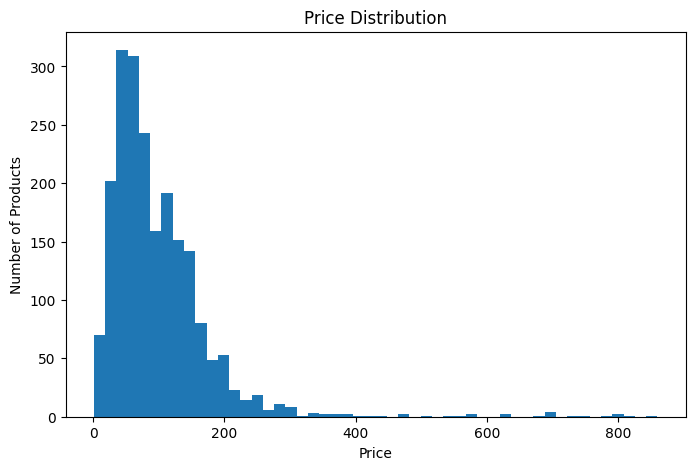

In [13]:
# xem phân bố giá của sản phẩm
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(products["price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

### Nhận xét

Từ biểu đồ phân bố giá có thể thấy:

- Phần lớn sản phẩm tập trung ở khoảng **50 – 150 USD**.
- Khi giá tăng lên thì số lượng sản phẩm giảm dần.
- Có một số sản phẩm có giá rất cao (trên **400 – 800 USD**), đây có thể được xem là **các giá trị ngoại lai (outliers)**.

Điều này cho thấy tập dữ liệu chủ yếu gồm các sản phẩm **phân khúc trung bình**, trong khi các sản phẩm cao cấp chiếm tỷ lệ nhỏ.

count     20.00000
mean     250.00000
std       17.65458
min      223.00000
25%      237.00000
50%      250.00000
75%      261.75000
max      282.00000
Name: count, dtype: float64


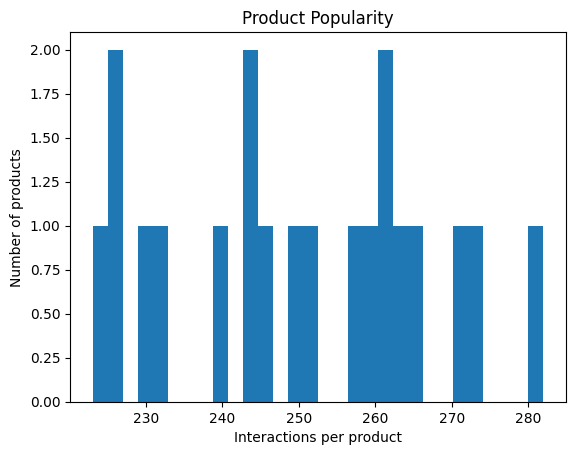

In [18]:
# ==============================
# PRODUCT POPULARITY
# ==============================

product_popularity = interactions["product_id"].value_counts()

print(product_popularity.describe())
plt.hist(product_popularity, bins=30)
plt.title("Product Popularity")
plt.xlabel("Interactions per product")
plt.ylabel("Number of products")
plt.show()

### Phân bố độ phổ biến của sản phẩm

Biểu đồ trên thể hiện số lượng tương tác mà mỗi sản phẩm nhận được trong tập dữ liệu.

**Nhận xét:**

- Hầu hết các sản phẩm nhận được khoảng **230 đến 270 lượt tương tác**.
- Phân bố tương tác giữa các sản phẩm khá **đồng đều**, không có sản phẩm nào vượt trội quá nhiều so với phần còn lại.
- Không xuất hiện các outlier quá lớn trong phân bố tương tác.

**Ý nghĩa:**

- Dữ liệu không thể hiện rõ hiện tượng **long-tail distribution** thường thấy trong các hệ thống gợi ý thực tế.
- Do mức độ phổ biến của các sản phẩm khá cân bằng, hệ thống gợi ý sẽ cần dựa nhiều hơn vào:
  - **hành vi người dùng**
  - **độ tương đồng giữa các sản phẩm**
- Tuy nhiên, **product popularity** vẫn có thể được sử dụng như một feature trong mô hình ranking hoặc làm baseline recommendation.

## Tổng kết phân tích dữ liệu (EDA Summary)

Qua quá trình phân tích dữ liệu ban đầu, có thể rút ra một số nhận xét chính như sau:

### 1. Tổng quan dataset

Tập dữ liệu bao gồm:

- **1000 người dùng**
- **2079 sản phẩm**
- **5000 lượt tương tác**

Số lượng tương tác trung bình khoảng **5 tương tác mỗi người dùng**, cho thấy dữ liệu khá **thưa (sparse)**. Đây là đặc điểm phổ biến trong các hệ thống gợi ý sản phẩm.

### 2. Phân bố loại tương tác

Các loại tương tác của người dùng với sản phẩm bao gồm:

- View: 3526
- AddToCart: 744
- Purchase: 460
- Like: 270

Có thể thấy rằng phần lớn tương tác là **View**, trong khi các hành động thể hiện mức độ quan tâm cao hơn như **AddToCart** và **Purchase** chiếm tỷ lệ nhỏ hơn. Điều này phản ánh hành vi phổ biến của người dùng trong các hệ thống thương mại điện tử: người dùng thường xem nhiều sản phẩm nhưng chỉ mua một số ít.

### 3. Phân tích giá sản phẩm

Phân bố giá cho thấy phần lớn sản phẩm nằm trong khoảng giá **thấp đến trung bình**, trong khi một số sản phẩm có giá cao xuất hiện với tần suất thấp hơn. Ngoài ra, tồn tại một số **giá trị ngoại lệ (outliers)** ở mức giá cao.

### 4. Ý nghĩa đối với hệ thống gợi ý

Từ các phân tích trên, có thể rút ra một số điểm quan trọng cho việc xây dựng hệ thống gợi ý:

- Các tương tác như **Purchase** và **AddToCart** có thể được xem là tín hiệu mạnh về sở thích của người dùng.
- Các tương tác **View** có thể được sử dụng như tín hiệu yếu hơn.
- Dữ liệu tương tác khá thưa, do đó các phương pháp gợi ý cần xử lý tốt dữ liệu sparse.

Các kết quả EDA này sẽ được sử dụng làm cơ sở cho bước tiếp theo là **tiền xử lý dữ liệu (data preprocessing)** và **xây dựng mô hình gợi ý sản phẩm**.